# 03 — Attack Evaluation

This notebook analyzes the adversarial robustness evaluation already performed
for AMCShield.

The following attacks are evaluated:

1. FGSM
2. PGD
3. MIM
4. C&W
5. Black-box transfer attack

The notebook loads the generated CSV results from `results/`.

No attacks are executed again.

In [7]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RESULTS = ROOT / "results"

print("ROOT:", ROOT)
print("RESULTS:", RESULTS)

files = {
    "FGSM": "fgsm_results.csv",
    "PGD": "pgd_results.csv",
    "MIM": "mim_results.csv",
    "C&W": "cw_results.csv",
    "Black-box": "blackbox_results.csv",
}

results = {}

for name, filename in files.items():
    path = RESULTS / filename
    print(f"Loading {name}: {path}")

    results[name] = pd.read_csv(path)

    print(f"  Loaded: {len(results[name])} rows")

print("\nAll attack result files loaded successfully.")

ROOT: d:\MediCaps University\7 SEM\Project 1\AMCShield
RESULTS: d:\MediCaps University\7 SEM\Project 1\AMCShield\results
Loading FGSM: d:\MediCaps University\7 SEM\Project 1\AMCShield\results\fgsm_results.csv
  Loaded: 26 rows
Loading PGD: d:\MediCaps University\7 SEM\Project 1\AMCShield\results\pgd_results.csv
  Loaded: 26 rows
Loading MIM: d:\MediCaps University\7 SEM\Project 1\AMCShield\results\mim_results.csv
  Loaded: 26 rows
Loading C&W: d:\MediCaps University\7 SEM\Project 1\AMCShield\results\cw_results.csv
  Loaded: 26 rows
Loading Black-box: d:\MediCaps University\7 SEM\Project 1\AMCShield\results\blackbox_results.csv
  Loaded: 26 rows

All attack result files loaded successfully.


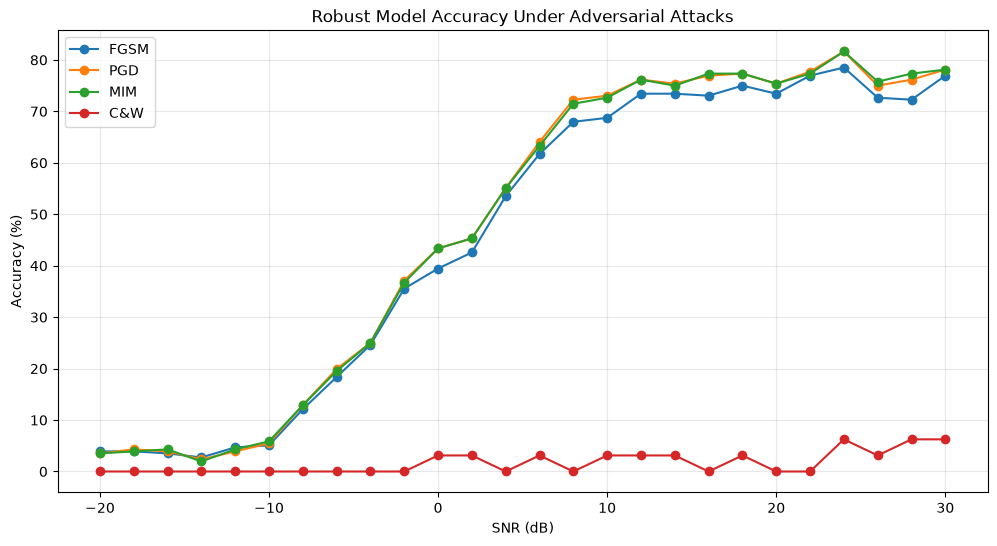

In [8]:
plt.figure(figsize=(12, 6))

plt.plot(
    results["FGSM"]["snr"],
    results["FGSM"]["fgsm_accuracy"] * 100,
    marker="o",
    label="FGSM"
)

plt.plot(
    results["PGD"]["snr"],
    results["PGD"]["pgd_accuracy"] * 100,
    marker="o",
    label="PGD"
)

plt.plot(
    results["MIM"]["snr"],
    results["MIM"]["mim_accuracy"] * 100,
    marker="o",
    label="MIM"
)

plt.plot(
    results["C&W"]["snr"],
    results["C&W"]["cw_accuracy"] * 100,
    marker="o",
    label="C&W"
)

plt.xlabel("SNR (dB)")
plt.ylabel("Accuracy (%)")
plt.title("Robust Model Accuracy Under Adversarial Attacks")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

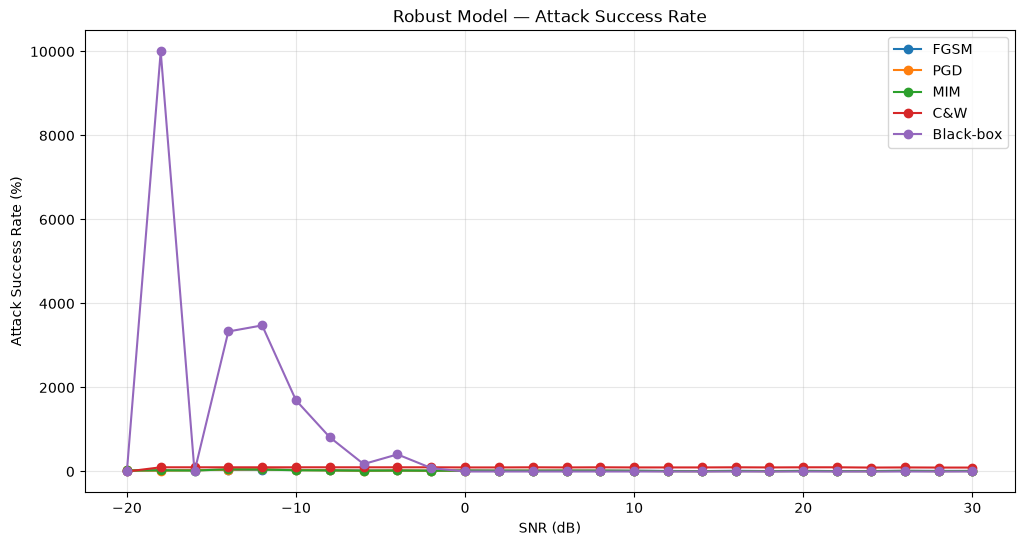

In [9]:
plt.figure(figsize=(12, 6))

for name, df in results.items():
    plt.plot(
        df["snr"],
        df["attack_success_rate"] * 100,
        marker="o",
        label=name
    )

plt.xlabel("SNR (dB)")
plt.ylabel("Attack Success Rate (%)")
plt.title("Robust Model — Attack Success Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

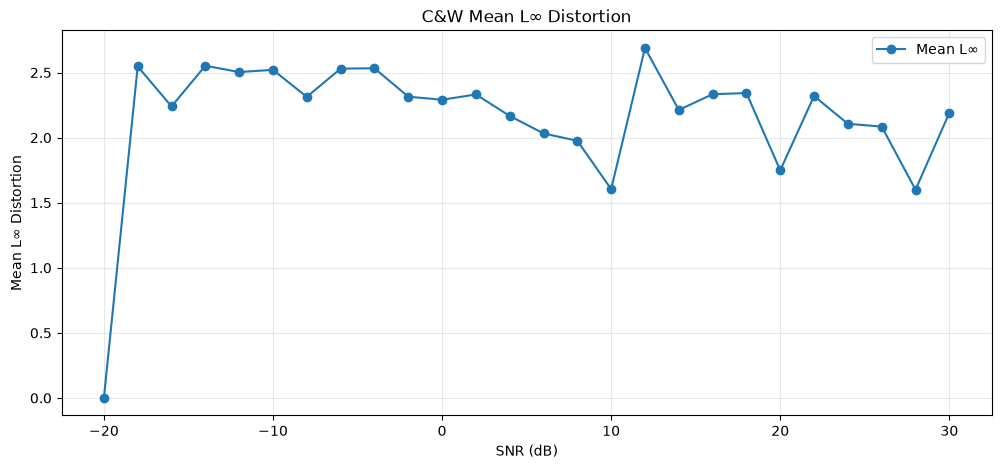

In [10]:
cw = results["C&W"]

plt.figure(figsize=(12, 5))
plt.plot(cw["snr"], cw["mean_linf"], marker="o", label="Mean L∞")
plt.xlabel("SNR (dB)")
plt.ylabel("Mean L∞ Distortion")
plt.title("C&W Mean L∞ Distortion")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

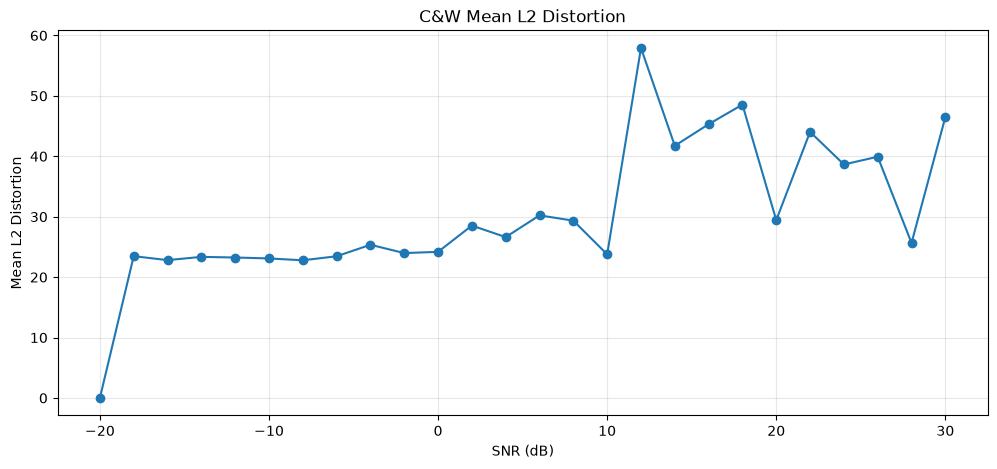

In [11]:
plt.figure(figsize=(12, 5))
plt.plot(cw["snr"], cw["mean_l2"], marker="o")
plt.xlabel("SNR (dB)")
plt.ylabel("Mean L2 Distortion")
plt.title("C&W Mean L2 Distortion")
plt.grid(alpha=0.3)
plt.show()

### Evaluation Note

The C&W evaluation is not an ε=0.02 bounded attack.

Unlike FGSM, PGD and MIM, the current C&W implementation does not apply
the same L∞ projection constraint. Therefore its distortion statistics
are reported separately using L∞ and L2 metrics.